# Supplementary Fig. 14 — observed vs expected VAF across Horizon Myeloid Reference Standard dilutions

Each datapoint is one validated variant at one dilution in one technical replicate: observed DCS VAF (y)
vs expected VAF (x), coloured by decision category (blue = detected, green = borderline eligible for
longitudinal rescue, orange = borderline single-read, red = not above position error-rate, grey = not
detected). Dotted lines are the 95% CI for the VAF expected from binomial counting noise at ~2000x. The
legend and inset MAE/MRE table in the published figure are Illustrator additions.

## Data availability

The Horizon spreadsheet included here holds every value plotted in this panel - the expected VAF of each
validated variant at each dilution, alongside the observed VAF in both technical replicates - and the same
values are published as **Table S1** of the paper.

The per-sample DCS variant-call files are **not distributed with this code**. The dilution series was made
by diluting the reference standard into peripheral-blood DNA from a single 65-year-old individual (hDNA,
the `SEM11503` sample IDs), so the dilutions and the undiluted hDNA sample are largely or entirely that
individual's DNA, and the call files carry their germline genotypes. The sequencing data for the Myeloid Reference Standard dilutions and the hDNA sample is **not
deposited**: the EGA submission covers the UKCTOCS participant samples only. This panel therefore cannot
be re-run from public data, but every value it plots is published as **Table S1** of the paper, and is
included here in `Data_files/Horizon_reference_standards/Horizon_Myeloid_Reference_DCS.xlsx`.

| file | used for | location |
|---|---|---|
| `Horizon_reference_standards/*_DCS_beta_binomial_SNV_all_variant_calls.txt` | per-sample DCS variant calls after the noise model | not distributed |
| `Horizon_reference_standards/Horizon_Myeloid_Reference_DCS.xlsx` | validated variants and their expected VAF at each dilution | Data_files |

The figure saved below is the output of a run with the call files in place.


In [15]:
# imported packages
import re
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
#colours (colorbrewer2)
blue3   = '#6baed6'
green3  = '#74c476'
orange3 = '#fd8d3c'
grey2   = '#cccccc'
grey3   = '#969696'
grey5   = '#252525'

In [17]:
# Variants to search
TARGETS = [
    ("BCOR", "p.Q1174fs*8"),
    ("KRAS", "p.G13D"),
    ("RUNX1", "p.M240I"),
    ("NRAS", "p.Q61L"),
    ("ASXL1", "p.W796C"),
    ("CBL", "p.S403F"),
    ("DNMT3A", "p.R882C"),
    ("EZH2", "p.R413Q"),
    ("FLT3", "ITD"),
    ("FLT3", "p.D835Y"),
    ("IDH1", "p.R132C"),
    ("IDH2", "p.R172K"),
    ("JAK2", "p.F537-K539>L"),
    ("JAK2", "p.V617F"),
    ("NPM1", "p.W288fs*12"),
    ("SF3B1", "p.G740E"),
    ("TET2", "p.R1261H"),
    ("TP53", "p.S241F"),
]

# --- helpers ---
def flexible_read_table(p: str) -> pd.DataFrame:
    """Try TSV first, then CSV/whitespace-delimited."""
    try:
        return pd.read_csv(p, sep="\t")
    except Exception:
        return pd.read_csv(p, sep=None, engine="python")

def pick_col(df: pd.DataFrame, candidates):
    """Pick the first case-insensitive match for a column name."""
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    return None

def normalise_vaf_to_percent(x):
    """Return VAF as float percent if possible."""
    if pd.isna(x):
        return x
    s = str(x).strip()
    s = s.replace('%','')
    try:
        v = float(s)
        # Heuristic: if <=1, assume fraction and convert to %
        return v*100 if v <= 1 else v
    except ValueError:
        return pd.NA

def aa_to_regex(aa_change: str) -> str:
    """
    Build a tolerant regex:
      - For frameshifts like 'p.W288fs*12' allow an optional inserted letter: W288[A-Z]?fs*12
      - For FLT3 ITD, match 'ITD' anywhere
      - For JAK2 p.F537-K539>L, match common encodings (delinsL, >L, or K539L)
      - Otherwise exact string match
    """
    if "ITD" in aa_change:
        return r"ITD"
    m = re.search(r"(p\.\w+\d+)fs\*(\d+)", aa_change)
    if m:
        base = re.escape(m.group(1))
        n = m.group(2)
        return rf"{base}[A-Z]?fs\*{n}"
    if aa_change == "p.F537-K539>L":
        return r"(F537[_-]?K539.*(>L|delinsL))|(K539L)"
    return re.escape(aa_change)

def process_file(path: str, targets, sample_name):
    df = flexible_read_table(path)

    # Column mapping (case-insensitive, with common alternates)
    col_gene = pick_col(df, ["gene","Gene","Gene.refGene","GENE"])
    col_aa   = pick_col(df, ["AA_change","AAChange","Protein_change","HGVSp_Short","HGVSp","amino_acid_change"])
    col_vaf  = pick_col(df, ["VAF","vaf","AF","allele_frequency","tumor_f","Tumor_Freq","Tumor_AF"])
    col_call = pick_col(df, ["call","Call","classification","Classification","FILTER","Filter"])
    col_pvalue = pick_col(df, ["p-value"])
    col_position = pick_col(df, ["position ID"])
    col_depth = pick_col(df, ["total depth"])
    col_vdepth = pick_col(df, ["variant depth"])
    col_RSID = pick_col(df, ['RSID'])
    col_posread = pick_col(df, ['mean_position_in_read'])
    col_bias = pick_col(df, ['strand_bias_fisher_p_value_phred'])
    col_exac = pick_col(df, ['exac_all'])    

    # If any critical column is missing, make empty output noting the issue
    if not all([col_gene, col_aa]):
        return pd.DataFrame([{
            "Sample": Path(path).stem,
            "Gene": None, "Variant_requested": None,
            "Variant_found": None, "VAF_percent": None,
            "Call": None, "Note": "Missing gene/AA columns",
            "p-value": None, "Note": "Missing p-value",
            "position ID": None, "Note": "Missing position ID",
            "total depth": None, "Note": "Missing total depth",
            "variant depth": None, "Note": "Missing variant depth",
            "RSID": None, "Note": "Missing RSID",
            "mean_position_in_read": None, "Note": "Missing mean position in read",
            "strand_bias_fisher_p_value_phred": None, "Note": "Missing strand bias",
            "exac_all": None, "Note": "Missing exac frequency"
        }])

    # Prepare typed columns
    if col_vaf:
        vafs = df[col_vaf].apply(normalise_vaf_to_percent)
    else:
        vafs = pd.Series([pd.NA]*len(df))

    # Case-normalised gene
    gene_series = df[col_gene].astype(str).str.upper()
    aa_series   = df[col_aa].astype(str)

    rows = []
    for gene, aa_req in targets:
        # restrict by gene first (case-insensitive exact)
        mask_gene = gene_series.eq(gene.upper())
        sub = df[mask_gene].copy()
        if sub.empty:
            rows.append({
                "Sample": sample_name,
                "Gene": gene,
                "Variant_requested": aa_req,
                "Variant_found": None,
                "VAF_percent": None,
                "Call": "NOT FOUND",
                "p-value": None,
                "position ID": None,
                "Note": "Gene present? no",
                "total depth": None,
                "variant depth": None,
                "RSID": None,
                "mean_position_in_read": None,
                "strand_bias_fisher_p_value_phred": None,
                "exac_all": None
            })
            continue

        # find by tolerant AA regex
        pattern = aa_to_regex(aa_req)
        aa_sub = aa_series[mask_gene]
        hit_idx = aa_sub[aa_sub.str.contains(pattern, na=False, regex=True)].index

        if len(hit_idx) == 0:
            rows.append({
                "Sample": sample_name,
                "Gene": gene,
                "Variant_requested": aa_req,
                "Variant_found": None,
                "VAF_percent": None,
                "Call": "NOT FOUND",
                "p-value": None,
                "position ID": None,
                "Note": "",
                "total depth": None,
                "variant depth": None,
                "RSID": None,
                "mean_position_in_read": None,
                "strand_bias_fisher_p_value_phred": None,
                "exac_all": None
            })
        else:
            # If multiple, report the one with the highest VAF (common in duplicate annotations)
            sub_hits = df.loc[hit_idx].copy()
            if col_vaf:
                sub_hits["_vaf_num"] = pd.to_numeric(sub_hits[col_vaf].astype(str).str.replace("%",""), errors="coerce")
                sub_hits["_vaf_num"] = sub_hits["_vaf_num"].apply(normalise_vaf_to_percent)
                sub_hits = sub_hits.sort_values("_vaf_num", ascending=False)
            top = sub_hits.iloc[0]
            rows.append({
                "Sample": sample_name,
                "Gene": gene,
                "Variant_requested": aa_req,
                "Variant_found": top[col_aa],
                "VAF_percent": normalise_vaf_to_percent(top[col_vaf]) if col_vaf else None,
                "Call": (top[col_call] if col_call in top else None),
                "p-value": (top[col_pvalue] if col_pvalue in top else None),
                "position ID": (top[col_position] if col_position in top else None),
                "total depth": (top[col_depth] if col_depth in top else None),
                "variant depth": (top[col_vdepth] if col_vdepth in top else None),
                "RSID": (top[col_RSID] if col_RSID in top else None),
                "mean_position_in_read": (top[col_posread] if col_posread in top else None),
                "strand_bias_fisher_p_value_phred": (top[col_bias] if col_bias in top else None),
                "exac_all": (top[col_exac] if col_exac in top else None),
                "Note": ""
            })

    return pd.DataFrame(rows)

In [18]:
sample_names = ['Myeloid_100A', 'Myeloid_100B', 'Myeloid_10A', 'Myeloid_10B', 'Myeloid_1B', 'Myeloid_1A', 'Myeloid_0_1B', 'Myeloid_0_1A', 'SEM11503B', 'SEM11503A']

tables = {}

for sample_name in sample_names:
    INPUT_GLOB = 'Data_files/Horizon_reference_standards/'+sample_name+'_SNV_watson_code_DCS_beta_binomial_SNV_all_variant_calls.txt'
    paths = sorted(glob(INPUT_GLOB))
    if not paths:
        raise FileNotFoundError(f"No files matched: {INPUT_GLOB}")
    
    all_results = pd.concat([process_file(p, TARGETS, sample_name) for p in paths], ignore_index=True)
    
    # Nice ordering
    all_results["Variant_requested"] = pd.Categorical(
        all_results["Variant_requested"],
        [v for _, v in TARGETS],
        ordered=True
    )
    all_results = all_results.sort_values(["Sample","Variant_requested"]).reset_index(drop=True)
    tables[sample_name] = all_results
    
    # Save
    out_csv = 'Data_files/Horizon_reference_standards/'+sample_name+'_SNV_watson_code_DCS_beta_binomial_SNV_all_variant_calls_samples_of_interest_Aug2025.csv'
    
    # Optional: a quick wide matrix of VAF% per sample (one column per requested variant)
    wide = (
        all_results
        .pivot_table(index="Sample",
                     columns=["Gene","Variant_requested"],
                     values="VAF_percent", aggfunc="first")
    )
    # display(all_results)
    # display(wide)
    
    # print(f"Saved: {out_csv}")

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_57885/2567946710.py:143: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hit_idx = aa_sub[aa_sub.str.contains(pattern, na=False, regex=True)].index
/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_57885/4035380284.py:28: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="Sample",
/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_57885/2567946710.py:143: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hit_idx = aa_sub[aa_sub.str.contains(pattern, na=False, regex=True)].index
/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_57885/4035380284.py:28: FutureW

In [19]:
# Concatenate all tables; force Sample to be the dict key
combined = pd.concat(
    [df.assign(Sample=key) for key, df in tables.items()],
    ignore_index=True
)

# Keep your original ordering
combined["Sample"] = pd.Categorical(combined["Sample"], categories=sample_names, ordered=True)
combined["Variant_requested"] = pd.Categorical(combined["Variant_requested"], [v for _, v in TARGETS], ordered=True)
combined = combined.sort_values(["Sample","Variant_requested"]).reset_index(drop=True)

# Save + (optional) wide matrix of VAF% across all samples

wide_all = (
    combined.pivot_table(index="Sample",
                         columns=["Gene","Variant_requested"],
                         values="VAF_percent", aggfunc="first")
)
wide_all_flipped = wide_all.T 

# display(combined)
# display(wide_all_flipped)


/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_57885/3958393958.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  combined.pivot_table(index="Sample",


In [20]:
sample_to_dilution_mapper = {'Myeloid_100A': '100%',
                             'Myeloid_100B': '100%',
                             'Myeloid_10A': '25%',
                             'Myeloid_10B': '25%',
                             'Myeloid_1A': '1%',
                             'Myeloid_1B': '1%',
                             'Myeloid_0_1A': '0.1%',
                             'Myeloid_0_1B': '0.1%'}

other_detected_real_variants = {'Myeloid_100A': {'BCOR p.Q1174fs*8': 59.20,
                                            'RUNX1 p.M240I': 34.00,
                                            'EZH2 p.R413Q': 4.00,
                                            'FLT3 ITD': 4.10,
                                            'JAK2 p.F537-K539>L': 3.67,
                                            'NPM1 p.W288fs*12': 4.16},
                          'Myeloid_100B': {'BCOR p.Q1174fs*8': 60.60,
                                            'RUNX1 p.M240I': 32.80,
                                            'EZH2 p.R413Q': 4.40,
                                            'FLT3 ITD': 3.50,
                                            'JAK2 p.F537-K539>L': 4.20,
                                            'NPM1 p.W288fs*12': 3.90},
                          'Myeloid_10A': {'BCOR p.Q1174fs*8': 10.08,
                                            'RUNX1 p.M240I': 9.61,
                                            'EZH2 p.R413Q': 1.08,
                                            'FLT3 ITD': 1.11,
                                            'JAK2 p.F537-K539>L': 1.18,
                                            'NPM1 p.W288fs*12': 1.21},
                          'Myeloid_10B': {'BCOR p.Q1174fs*8': 10.42,
                                            'RUNX1 p.M240I': 10.14,
                                            'EZH2 p.R413Q': 1.25,
                                            'FLT3 ITD': 1.15,
                                            'JAK2 p.F537-K539>L': 1.37,
                                            'NPM1 p.W288fs*12': 1.03}}

other_detected_lowpval_variants = {'Myeloid_1A': {'BCOR p.Q1174fs*8': 0.056,
                                            'RUNX1 p.M240I': 0.167,
                                            'EZH2 p.R413Q': 0.091},
                          'Myeloid_1B': {'BCOR p.Q1174fs*8': 0.176,
                                            'RUNX1 p.M240I': 0.254},
                          'Myeloid_0_1A': {'BCOR p.Q1174fs*8': 0.045,
                                            'RUNX1 p.M240I': 0.148},
                          'Myeloid_0_1B': {'RUNX1 p.M240I': 0.092}}

In [21]:
def expected_by_dilution_from_xlsx(path, sheet="DCS"):
    """
    Returns: {
        '100%': {'BCOR p.Q1174fs*8': 70.0, ...},
        '25%' : {...},
        '1%'  : {...},
        '0.1%': {...}
    }
    """
    # Read raw so we can parse the two header rows
    df = pd.read_excel(path, sheet_name=sheet, header=None)

    # Row 0 = dilution group titles, Row 1 = subheaders ("Expected (%)", "VAF1 (%)", "VAF2 (%)")
    top = df.iloc[0].fillna(method="ffill")   # forward-fill merged titles across their 3 columns
    sub = df.iloc[1]

    # Data starts at row 2
    start_row = 2
    variants = df.iloc[start_row:, 0].astype(str)

    # Drop any summary rows like "% detected in DCS"
    valid_rows = ~variants.str.startswith("%")

    out = {}
    for col_idx, subname in enumerate(sub):
        if subname == "Expected (%)":
            # Extract dilution label (e.g., "25%") from the top header row
            title = str(top.iloc[col_idx])
            m = re.search(r"([0-9]+(?:\.[0-9]+)?)\s*%", title)
            if not m:
                continue
            dilution_key = f"{m.group(1)}%"

            # Pull numeric expected values and align to variants
            expected_vals = pd.to_numeric(df.iloc[start_row:, col_idx], errors="coerce")
            expected_vals = expected_vals[valid_rows].dropna()

            var_names = variants.loc[expected_vals.index]
            out[dilution_key] = dict(zip(var_names, expected_vals.astype(float)))

    return out

# ---- Usage ----
expected_by_dilution = expected_by_dilution_from_xlsx('Data_files/Horizon_reference_standards/Horizon_Myeloid_Reference_DCS.xlsx', sheet="DCS")

# Peek
for k in ["100%", "25%", "1%", "0.1%"]:
    if k in expected_by_dilution:
        print(k, "→", len(expected_by_dilution[k]), "variants")

100% → 18 variants
25% → 18 variants
1% → 18 variants
0.1% → 18 variants


/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_57885/1675354999.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  top = df.iloc[0].fillna(method="ffill")   # forward-fill merged titles across their 3 columns


In [22]:
#look at all variants to work out the specificity:

def process_file_all_variants(path: str, sample_name):
    df = flexible_read_table(path)

    # Column mapping
    col_gene = pick_col(df, ["gene","Gene","Gene.refGene","GENE"])
    col_aa   = pick_col(df, ["AA_change","AAChange","Protein_change","HGVSp_Short","HGVSp","amino_acid_change"])
    col_vaf  = pick_col(df, ["VAF","vaf","AF","allele_frequency","tumor_f","Tumor_Freq","Tumor_AF"])
    col_call = pick_col(df, ["call","Call","classification","Classification","FILTER","Filter"])
    col_pvalue = pick_col(df, ["p-value"])
    col_position = pick_col(df, ["position ID"])
    col_depth = pick_col(df, ["total depth"])
    col_vdepth = pick_col(df, ["variant depth"])
    col_RSID = pick_col(df, ['RSID'])
    col_posread = pick_col(df, ['mean_position_in_read'])
    col_bias = pick_col(df, ['strand_bias_fisher_p_value_phred'])
    col_exac = pick_col(df, ['exac_all'])    

    # VAF normalisation
    if col_vaf:
        df["VAF_percent"] = df[col_vaf].apply(normalise_vaf_to_percent)
    else:
        df["VAF_percent"] = pd.NA

    # Add sample name
    df["Sample"] = sample_name

    # Keep/rename columns you care about
    keep_cols = [
        "Sample",
        col_gene if col_gene else None,
        col_aa if col_aa else None,
        "VAF_percent",
        col_call,
        col_pvalue,
        col_position,
        col_depth,
        col_vdepth,
        col_RSID,
        col_posread,
        col_bias,
        col_exac
    ]
    # Drop any Nones
    keep_cols = [c for c in keep_cols if c]

    return df[keep_cols]

In [23]:
sample_names = ['Myeloid_100A', 'Myeloid_100B', 'Myeloid_10A', 'Myeloid_10B', 'Myeloid_1B', 'Myeloid_1A', 'Myeloid_0_1B', 'Myeloid_0_1A', 'SEM11503B', 'SEM11503A']

tables_all_variants = {}

for sample_name in sample_names:
    INPUT_GLOB = 'Data_files/Horizon_reference_standards/'+sample_name+'_SNV_watson_code_DCS_beta_binomial_SNV_all_variant_calls.txt'
    paths = sorted(glob(INPUT_GLOB))
    if not paths:
        raise FileNotFoundError(f"No files matched: {INPUT_GLOB}")
    
    all_results = pd.concat([process_file_all_variants(p, sample_name) for p in paths], ignore_index=True)
    
    # Nice ordering
    all_results = all_results.sort_values(["Sample"]).reset_index(drop=True)
    tables_all_variants[sample_name] = all_results

# Concatenate all tables; force Sample to be the dict key
combined = pd.concat(
    [df.assign(Sample=key) for key, df in tables.items()],
    ignore_index=True
)

# Keep your original ordering
combined["Sample"] = pd.Categorical(combined["Sample"], categories=sample_names, ordered=True)
combined = combined.sort_values(["Sample"]).reset_index(drop=True)

# Save + (optional) wide matrix of VAF% across all samples

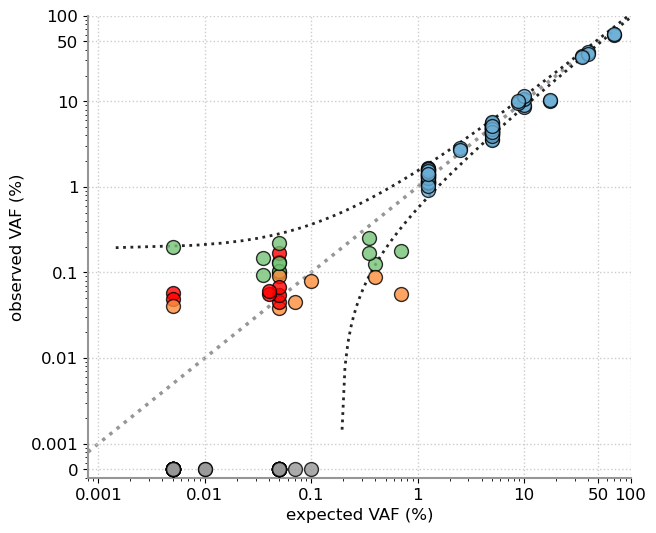

In [24]:
fig, ax1 = plt.subplots(1, 1, figsize = (7, 6))

plt.rcParams['ps.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.subplots_adjust(wspace = 0.4)

expected_observed_real = []
expected_observed_rescued_pval = []
expected_observed_errors = []
longitudinal_real = []
longitudinal_errors = []
blue_vars = []
orange_vars = []
green_vars = []
red_vars = []
expected_observed_not_detected = []

all_variants = {}
    
for sample_name, df in tables.items():
    if sample_name[0] == 'M':
        df = df.copy()
        df["VAF_percent"] = pd.to_numeric(df["VAF_percent"], errors="coerce")
        df["p-value"] = pd.to_numeric(df["p-value"], errors="coerce")
        df['variant'] = df["Gene"].astype(str) + " " + df["Variant_requested"].astype(str)
    
        dilution = sample_to_dilution_mapper[sample_name]
    
        for variant, expected_VAF in expected_by_dilution[dilution].items():
            df_variant = df[df['variant']==variant]
            #only set in the else-branch below; initialise so a variant recovered from the
            #'other_detected_*' dictionaries records nan rather than the previous iteration's value
            pvalue = np.nan
            variant_reads = df_variant['variant depth'].to_list()[0]

            plotted = 0
            total_depth = df_variant['total depth'].to_list()[0]
            if df_variant.empty or df_variant['VAF_percent'].isna().all():
                if sample_name in other_detected_real_variants.keys():
                    if variant in other_detected_real_variants[sample_name].keys():
                        observed_VAF = other_detected_real_variants[sample_name][variant]
                        color = blue3
                        plotted+=1
                            
                if sample_name in other_detected_lowpval_variants.keys():
                    if variant in other_detected_lowpval_variants[sample_name].keys():
                        observed_VAF = other_detected_lowpval_variants[sample_name][variant]
                        color = green3
                        plotted+=1
                        
                if plotted == 0:
                    observed_VAF = 0.0005
                    call = 'NOT DETECTED'
                    color = grey3
            else:
                observed_VAF = df_variant['VAF_percent'].to_list()[0]
                call = df_variant['Call'].to_list()[0]
                # print(call)
                pvalue = df_variant['p-value'].to_list()[0]
                if call == 'REAL VARIANT':
                    color = blue3
                else:
                    if pvalue<0.1:
                        color = green3
                    else:
                        color = 'red'

            if (variant_reads == 1) and (color == green3):
                color = orange3

            if variant == 'BCOR p.Q1174fs*8':
                if sample_name in ['Myeloid_1A', 'Myeloid_0_1A']:
                    color = orange3 #variant reads = 1, p-value 0.00389

            if color == blue3:
                expected_observed_real.append((expected_VAF, observed_VAF))
                longitudinal_real.append((expected_VAF, observed_VAF))
                blue_vars.append((sample_name, variant, round(observed_VAF, 3), pvalue, variant_reads, total_depth))
                
            if color == green3:
                expected_observed_rescued_pval.append((expected_VAF, observed_VAF))
                longitudinal_real.append((expected_VAF, observed_VAF))
                green_vars.append((sample_name, variant, round(observed_VAF, 3), round(pvalue, 5), variant_reads, total_depth))
            if color == 'red':
                expected_observed_errors.append((expected_VAF, observed_VAF))
                longitudinal_errors.append((expected_VAF, observed_VAF))
                red_vars.append((sample_name, variant, round(observed_VAF, 3), round(pvalue, 5), variant_reads, total_depth))
            if color == orange3:
                expected_observed_errors.append((expected_VAF, observed_VAF))
                longitudinal_errors.append((expected_VAF, observed_VAF))
                orange_vars.append((sample_name, variant, round(observed_VAF, 3), round(pvalue, 5), variant_reads, total_depth))
            if color == grey3:
                expected_observed_not_detected.append((expected_VAF, observed_VAF))

            if color in [blue3, green3, orange3, 'red']:
                if sample_name in all_variants.keys():
                    all_variants[sample_name][variant]=(variant_reads, total_depth)
                else:
                    all_variants[sample_name]={variant: (variant_reads, total_depth)}
                
    
            ax1.scatter(expected_VAF/100, observed_VAF/100, color = color, edgecolor = 'k', s = 100, label = k, alpha = 0.8, zorder = 50)

#Error lines
D = 2000 #mean_depth
x1=np.logspace(-2.71, 0, 100)
y1=np.logspace(-2.71, 0, 100)
f_low=[f-1.96*((f/D)**0.5) for f in x1]
f_low2=[]
for f in f_low:
    if f<0:
        f_low2.append(1e-8)
    else:
        f_low2.append(f)
ax1.plot(x1, f_low2, lw=2,color=grey5,alpha=1.0, zorder=2, ls=':')
ax1.plot(f_low2, x1, lw=2,color=grey5,alpha=1.0, zorder=2, ls=':')

# ---- Shade only where x>0.001 and y>0.001 ----
th = 1e-6
f_low2 = np.array(f_low2)  # make it an array
mask = (x1 > th) & (f_low2 > th)

# Build polygon from the masked segments of both curves
xs = np.concatenate([x1[mask],    f_low2[mask][::-1]])
ys = np.concatenate([f_low2[mask], x1[mask][::-1]])

# ax1.fill(xs, ys, alpha=0.15, facecolor=grey5, edgecolor='none', zorder=1)

ax1.plot([0.000008, 0.55], [0.000008, 0.55], color = grey3, lw = 2.5, linestyle = ':', zorder = 0)
            
ax1.set_xlabel('expected VAF (%)', fontsize = 12)
ax1.set_ylabel('observed VAF (%)', fontsize = 12)

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xlim(0.000008, 1.0)
ax1.set_ylim(0.000004, 1.0)
yticks = [0.000005, 0.00001, 0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
yticklabels = ['0', '0.001', '0.01' , '0.1', '1', '10', '50', '100']

xticks = [0.00001, 0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
xticklabels = ['0.001', '0.01' , '0.1', '1', '10', '50', '100']
ax1.set_xticks(xticks)
ax1.set_yticks(yticks)
ax1.set_xticklabels(xticklabels, fontsize = 12)
ax1.set_yticklabels(yticklabels, fontsize = 12)

#Only show the required axis lines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for axis in ['bottom','left']:
    ax1.spines[axis].set_linewidth(1.5)

for axis in ['bottom','left']:
    ax1.spines[axis].set_color(grey3)

ax1.grid(color = grey2, linewidth = 1, linestyle = ':', zorder = 0)

plt.show()